# 🌐 Arquiteturas Paralelas e Distribuídas

`Hardware` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Paralelismo, sincronização, sistemas distribuídos, consistência e escala.**

Computação paralela e distribuída: lei de Amdahl, threads, race conditions, latência de rede e trade-offs de consistência.


## 🖼️ Resultado visual

Este é o **cheat sheet** da matéria, gerado pelo código abaixo (a mesma lógica é reutilizada na célula de geração do PDF). As páginas são renderizadas automaticamente.


PDF gerado em Arquiteturas_Paralelas_Distribuidas.pdf
Páginas: 1


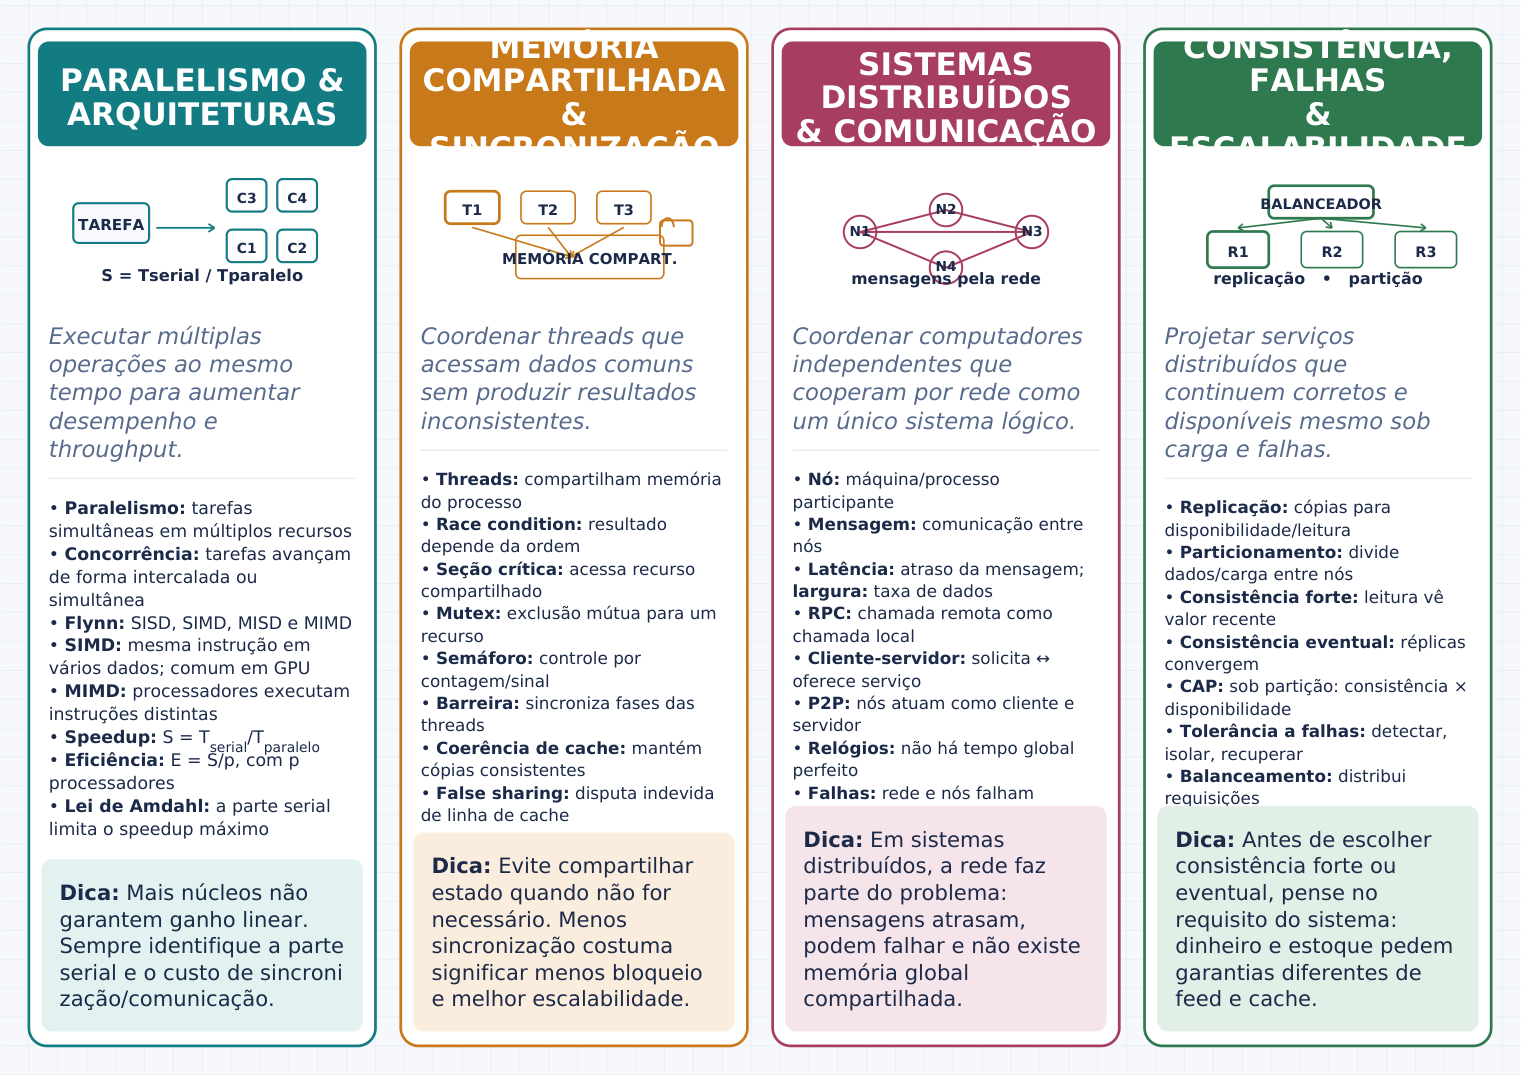

In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Arquiteturas_Paralelas_Distribuidas.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'PARALELISMO &amp;<br/>ARQUITETURAS',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'paralelismo',
        'idea': 'Executar múltiplas operações ao mesmo tempo para aumentar desempenho e throughput.',
        'formulas': [
            '<b>Paralelismo:</b> tarefas simultâneas em múltiplos recursos',
            '<b>Concorrência:</b> tarefas avançam de forma intercalada ou simultânea',
            '<b>Flynn:</b> SISD, SIMD, MISD e MIMD',
            '<b>SIMD:</b> mesma instrução em vários dados; comum em GPU',
            '<b>MIMD:</b> processadores executam instruções distintas',
            '<b>Speedup:</b> S = T<sub>serial</sub>/T<sub>paralelo</sub>',
            '<b>Eficiência:</b> E = S/p, com p processadores',
            '<b>Lei de Amdahl:</b> a parte serial limita o speedup máximo',
        ],
        'tip': 'Mais núcleos não garantem ganho linear. Sempre identifique a parte serial e o custo de sincronização/comunicação.',
    },
    {
        'title': 'MEMÓRIA COMPARTILHADA<br/>&amp; SINCRONIZAÇÃO',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'memoria',
        'idea': 'Coordenar threads que acessam dados comuns sem produzir resultados inconsistentes.',
        'formulas': [
            '<b>Threads:</b> compartilham memória do processo',
            '<b>Race condition:</b> resultado depende da ordem',
            '<b>Seção crítica:</b> acessa recurso compartilhado',
            '<b>Mutex:</b> exclusão mútua para um recurso',
            '<b>Semáforo:</b> controle por contagem/sinal',
            '<b>Barreira:</b> sincroniza fases das threads',
            '<b>Coerência de cache:</b> mantém cópias consistentes',
            '<b>False sharing:</b> disputa indevida de linha de cache',
        ],
        'tip': 'Evite compartilhar estado quando não for necessário. Menos sincronização costuma significar menos bloqueio e melhor escalabilidade.',
    },
    {
        'title': 'SISTEMAS DISTRIBUÍDOS<br/>&amp; COMUNICAÇÃO',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'distribuidos',
        'idea': 'Coordenar computadores independentes que cooperam por rede como um único sistema lógico.',
        'formulas': [
            '<b>Nó:</b> máquina/processo participante',
            '<b>Mensagem:</b> comunicação entre nós',
            '<b>Latência:</b> atraso da mensagem; <b>largura:</b> taxa de dados',
            '<b>RPC:</b> chamada remota como chamada local',
            '<b>Cliente-servidor:</b> solicita ↔ oferece serviço',
            '<b>P2P:</b> nós atuam como cliente e servidor',
            '<b>Relógios:</b> não há tempo global perfeito',
            '<b>Falhas:</b> rede e nós falham independentemente',
        ],
        'tip': 'Em sistemas distribuídos, a rede faz parte do problema: mensagens atrasam, podem falhar e não existe memória global compartilhada.',
    },
    {
        'title': 'CONSISTÊNCIA, FALHAS<br/>&amp; ESCALABILIDADE',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'consistencia',
        'idea': 'Projetar serviços distribuídos que continuem corretos e disponíveis mesmo sob carga e falhas.',
        'formulas': [
            '<b>Replicação:</b> cópias para disponibilidade/leitura',
            '<b>Particionamento:</b> divide dados/carga entre nós',
            '<b>Consistência forte:</b> leitura vê valor recente',
            '<b>Consistência eventual:</b> réplicas convergem',
            '<b>CAP:</b> sob partição: consistência × disponibilidade',
            '<b>Tolerância a falhas:</b> detectar, isolar, recuperar',
            '<b>Balanceamento:</b> distribui requisições',
            '<b>Escalabilidade:</b> crescer sem degradar demais',
        ],
        'tip': 'Antes de escolher consistência forte ou eventual, pense no requisito do sistema: dinheiro e estoque pedem garantias diferentes de feed e cache.',
    },
]

# ---------- layout ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title', fontName='DVCond-Bold', fontSize=17.2, leading=18.6, textColor=WHITE, alignment=1
)
STYLE_IDEA = ParagraphStyle(
    'idea', fontName='DVCond-Oblique', fontSize=12.6, leading=15.6, textColor=MUTED
)
STYLE_TIP = ParagraphStyle(
    'tip', fontName='DVCond', fontSize=11.7, leading=14.7, textColor=INK
)


def arrow(c, x1, y1, x2, y2, color, width=1.1, head=4):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    for delta in (2.55, -2.55):
        c.line(x2, y2, x2 + head * math.cos(ang + delta), y2 + head * math.sin(ang + delta))


def diagram_paralelismo(c, ox, oy, dw, dh, color):
    # one task split into four cores
    c.setStrokeColor(color); c.setLineWidth(1.2)
    c.setFillColor(HexColor('#F8FAFD'))
    c.roundRect(ox+dw*.08, oy+dh*.44, 42, 22, 3, fill=1, stroke=1)
    c.setFillColor(INK); c.setFont('DVCond-Bold',8.4); c.drawCentredString(ox+dw*.08+21, oy+dh*.44+7, 'TAREFA')
    for i in range(4):
        x=ox+dw*.58+(i%2)*28; y=oy+dh*.30+(i//2)*28
        c.setStrokeColor(color); c.roundRect(x,y,22,18,3,fill=0,stroke=1)
        c.setFillColor(INK); c.setFont('DVCond-Bold',7.7); c.drawCentredString(x+11,y+5,f'C{i+1}')
    arrow(c, ox+dw*.08+46, oy+dh*.55, ox+dw*.54, oy+dh*.55, color,1.0,4)
    c.setFillColor(INK); c.setFont('DVCond-Bold',9); c.drawCentredString(ox+dw*.5, oy+dh*.16, 'S = Tserial / Tparalelo')


def diagram_memoria(c, ox, oy, dw, dh, color):
    # threads to shared memory + lock
    for i,label in enumerate(['T1','T2','T3']):
        x=ox+dw*.08+i*42; y=oy+dh*.58
        c.setStrokeColor(color); c.roundRect(x,y,30,18,3,fill=0,stroke=1)
        c.setFillColor(INK); c.setFont('DVCond-Bold',8); c.drawCentredString(x+15,y+5,label)
        arrow(c,x+15,y-2,ox+dw*.49,oy+dh*.34,color,.9,3.5)
    c.setStrokeColor(color); c.roundRect(ox+dw*.31,oy+dh*.18,82,24,3,fill=0,stroke=1)
    c.setFillColor(INK); c.setFont('DVCond-Bold',8.3); c.drawCentredString(ox+dw*.31+41,oy+dh*.18+8,'MEMÓRIA COMPART.')
    c.setStrokeColor(color); c.setLineWidth(1.1); c.roundRect(ox+dw*.78,oy+dh*.42,18,14,2,fill=0,stroke=1)
    c.arc(ox+dw*.785,oy+dh*.49,ox+dw*.825,oy+dh*.62,0,180)


def diagram_distribuidos(c, ox, oy, dw, dh, color):
    pts=[(ox+dw*.22,oy+dh*.52),(ox+dw*.50,oy+dh*.68),(ox+dw*.78,oy+dh*.52),(ox+dw*.50,oy+dh*.26)]
    c.setStrokeColor(color); c.setLineWidth(1.1)
    for i,j in [(0,1),(1,2),(2,3),(3,0),(0,2)]: c.line(pts[i][0],pts[i][1],pts[j][0],pts[j][1])
    for idx,(x,y) in enumerate(pts):
        c.circle(x,y,9,stroke=1,fill=0); c.setFillColor(INK); c.setFont('DVCond-Bold',7.6); c.drawCentredString(x,y-2,f'N{idx+1}')
    c.setFillColor(INK); c.setFont('DVCond-Bold',8.7); c.drawCentredString(ox+dw*.5,oy+dh*.14,'mensagens pela rede')


def diagram_consistencia(c, ox, oy, dw, dh, color):
    # load balancer -> replicas
    c.setStrokeColor(color); c.roundRect(ox+dw*.34,oy+dh*.62,58,18,3,fill=0,stroke=1)
    c.setFillColor(INK); c.setFont('DVCond-Bold',8); c.drawCentredString(ox+dw*.34+29,oy+dh*.62+5,'BALANCEADOR')
    for i,lab in enumerate(['R1','R2','R3']):
        x=ox+dw*.14+i*52; y=oy+dh*.26
        c.setStrokeColor(color); c.roundRect(x,y,34,20,3,fill=0,stroke=1)
        c.setFillColor(INK); c.setFont('DVCond-Bold',8); c.drawCentredString(x+17,y+6,lab)
        arrow(c,ox+dw*.34+29,oy+dh*.62,x+17,y+22,color,.9,3.5)
    c.setFillColor(INK); c.setFont('DVCond-Bold',8.8); c.drawCentredString(ox+dw*.5,oy+dh*.14,'replicação   •   partição')


DIAGRAMS = {
    'paralelismo': diagram_paralelismo,
    'memoria': diagram_memoria,
    'distribuidos': diagram_distribuidos,
    'consistencia': diagram_consistencia,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']
    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11
    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 10.6
    leading = 13.7
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'], fontName='DVCond', fontSize=font_size, leading=leading, textColor=INK
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 470)
        if formula_h <= available_h or font_size <= 9.4:
            break
        font_size -= 0.1
        leading -= 0.1
    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Arquiteturas Paralelas e Distribuídas - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


# ===== renderização do PDF gerado =====
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Arquiteturas_Paralelas_Distribuidas.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF acima).

### 🟢 PARALELISMO & ARQUITETURAS

**Ideia:** Executar múltiplas operações ao mesmo tempo para aumentar desempenho e throughput.

- Paralelismo: tarefas simultâneas em múltiplos recursos
- Concorrência: tarefas avançam de forma intercalada ou simultânea
- Flynn: SISD, SIMD, MISD e MIMD
- SIMD: mesma instrução em vários dados; comum em GPU
- MIMD: processadores executam instruções distintas
- Speedup: S = T_serial/T_paralelo
- Eficiência: E = S/p, com p processadores
- Lei de Amdahl: a parte serial limita o speedup máximo

> 💡 **Dica:** Mais núcleos não garantem ganho linear. Sempre identifique a parte serial e o custo de sincronização/comunicação.

### 🟢 MEMÓRIA COMPARTILHADA & SINCRONIZAÇÃO

**Ideia:** Coordenar threads que acessam dados comuns sem produzir resultados inconsistentes.

- Threads: compartilham memória do processo
- Race condition: resultado depende da ordem
- Seção crítica: acessa recurso compartilhado
- Mutex: exclusão mútua para um recurso
- Semáforo: controle por contagem/sinal
- Barreira: sincroniza fases das threads
- Coerência de cache: mantém cópias consistentes
- False sharing: disputa indevida de linha de cache

> 💡 **Dica:** Evite compartilhar estado quando não for necessário. Menos sincronização costuma significar menos bloqueio e melhor escalabilidade.

### 🟢 SISTEMAS DISTRIBUÍDOS & COMUNICAÇÃO

**Ideia:** Coordenar computadores independentes que cooperam por rede como um único sistema lógico.

- Nó: máquina/processo participante
- Mensagem: comunicação entre nós
- Latência: atraso da mensagem; largura: taxa de dados
- RPC: chamada remota como chamada local
- Cliente-servidor: solicita ↔ oferece serviço
- P2P: nós atuam como cliente e servidor
- Relógios: não há tempo global perfeito
- Falhas: rede e nós falham independentemente

> 💡 **Dica:** Em sistemas distribuídos, a rede faz parte do problema: mensagens atrasam, podem falhar e não existe memória global compartilhada.

### 🟢 CONSISTÊNCIA, FALHAS & ESCALABILIDADE

**Ideia:** Projetar serviços distribuídos que continuem corretos e disponíveis mesmo sob carga e falhas.

- Replicação: cópias para disponibilidade/leitura
- Particionamento: divide dados/carga entre nós
- Consistência forte: leitura vê valor recente
- Consistência eventual: réplicas convergem
- CAP: sob partição: consistência × disponibilidade
- Tolerância a falhas: detectar, isolar, recuperar
- Balanceamento: distribui requisições
- Escalabilidade: crescer sem degradar demais

> 💡 **Dica:** Antes de escolher consistência forte ou eventual, pense no requisito do sistema: dinheiro e estoque pedem garantias diferentes de feed e cache.


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) LEI DE AMDALH: speedup maximo vs fracao paralela
   50% paralelo, 8 nucleos: S = 1.78x
   95% paralelo, 8 nucleos: S = 5.93x
   95% paralelo, 64 nucleos: S = 15.42x


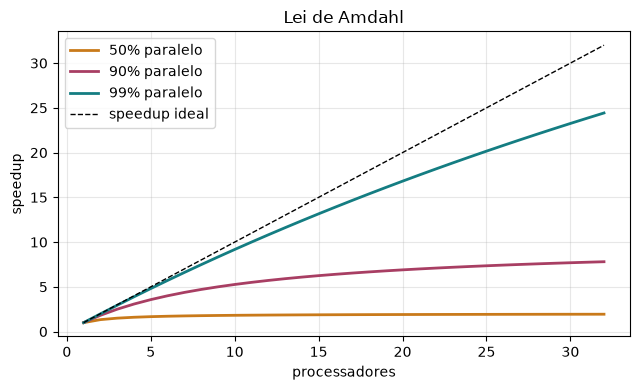


2) SOMA PARALELA com ThreadPoolExecutor
   soma serial  = 500000500000


   soma paralela= 500000500000  (iguais: True)

3) RACE CONDITION: contador sem lock vs com lock


   sem lock: esperado=800000, obtido=800000  -> RACE CONDITION


   com lock: esperado=800000, obtido=800000  -> OK

4) LATENCIA vs LARGURA DE BANDA
      100 KB -> tempo = 800.00 ms (latencia 0.1 ms)
     1000 KB -> tempo = 8000.00 ms (latencia 0.1 ms)
    10000 KB -> tempo = 80000.00 ms (latencia 0.1 ms)

OK - paralelismo e distribuicao demonstrados.


In [2]:

%matplotlib inline
import threading
import time
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

print("=" * 60)
print("1) LEI DE AMDALH: speedup maximo vs fracao paralela")
def amdahl(fr_par, p):
    return 1/((1 - fr_par) + fr_par/p)
print(f"   50% paralelo, 8 nucleos: S = {amdahl(0.5, 8):.2f}x")
print(f"   95% paralelo, 8 nucleos: S = {amdahl(0.95, 8):.2f}x")
print(f"   95% paralelo, 64 nucleos: S = {amdahl(0.95, 64):.2f}x")

procs = np.arange(1, 33)
plt.figure(figsize=(6.5, 4))
for frac, col, lbl in ((0.5, "#C97A1A", "50% paralelo"), (0.9, "#A83E63", "90% paralelo"),
                       (0.99, "#147D82", "99% paralelo")):
    plt.plot(procs, [amdahl(frac, p) for p in procs], lw=2, color=col, label=lbl)
plt.plot(procs, procs, "k--", lw=1, label="speedup ideal")
plt.title("Lei de Amdahl"); plt.xlabel("processadores"); plt.ylabel("speedup")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print("\n2) SOMA PARALELA com ThreadPoolExecutor")
def soma_par(vet, n_threads=4):
    with ThreadPoolExecutor(n_threads) as ex:
        partes = list(ex.map(lambda c: sum(c), np.array_split(vet, n_threads)))
    return sum(partes)
vet = np.arange(1, 1_000_001)
print(f"   soma serial  = {sum(vet)}")
print(f"   soma paralela= {soma_par(vet)}  (iguais: {sum(vet) == soma_par(vet)})")

print("\n3) RACE CONDITION: contador sem lock vs com lock")
contador = {"v": 0}
def inc(sem_lock, n=100000):
    for _ in range(n):
        if sem_lock is None:
            contador["v"] += 1
        else:
            with sem_lock:
                contador["v"] += 1
ths = [threading.Thread(target=inc, args=(None,)) for _ in range(8)]
for t in ths: t.start()
for t in ths: t.join()
print(f"   sem lock: esperado=800000, obtido={contador['v']}  -> RACE CONDITION")

contador["v"] = 0
lk = threading.Lock()
ths = [threading.Thread(target=inc, args=(lk,)) for _ in range(8)]
for t in ths: t.start()
for t in ths: t.join()
print(f"   com lock: esperado=800000, obtido={contador['v']}  -> OK")

print("\n4) LATENCIA vs LARGURA DE BANDA")
lat, bw = 0.1, 1000   # ms e Mbps
tamanhos = [100, 1000, 10000]   # KB
for kb in tamanhos:
    t_transf = kb*8e3/bw   # ms
    print(f"   {kb:>6} KB -> tempo = {t_transf:.2f} ms (latencia {lat} ms)")
print("\nOK - paralelismo e distribuicao demonstrados.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
